In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch as torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_score


def prepare_node_features(stocks, sectors, volatility, market_caps, pe_ratios, implied_vol, short_interest,
                           beta, operating_margin, return_on_equity, rsi_momentum, turnover, t):

    rows = []
    t = pd.to_datetime(t)
    if not stocks:
        return torch.empty((0, 2), dtype=torch.float32)
    for stock in stocks:
        # Get factors for stock at time t (or default values if missing)
        sector_id = sectors.loc[stock, 'sector_id'] if stock in sectors.index else 0
        market_cap = market_caps.loc[t, stock] if t in market_caps.index and stock in market_caps.columns else 0.0
        pe_ratio = pe_ratios.loc[t, stock] if t in pe_ratios.index and stock in pe_ratios.columns else 0.0
        implied_volatility = implied_vol.loc[t, stock] if t in implied_vol.index and stock in implied_vol.columns else 0.0
        short_int = short_interest.loc[t, stock] if t in short_interest.index and stock in short_interest.columns else 0.0
        beta_val = beta.loc[t, stock] if t in beta.index and stock in beta.columns else 0.0
        op_margin = operating_margin.loc[t, stock] if t in operating_margin.index and stock in operating_margin.columns else 0.0
        roe = return_on_equity.loc[t, stock] if t in return_on_equity.index and stock in return_on_equity.columns else 0.0
        rsi = rsi_momentum.loc[t, stock] if t in rsi_momentum.index and stock in rsi_momentum.columns else 0.0
        turn = turnover.loc[t, stock] if t in turnover.index and stock in turnover.columns else 0.0

        # Get volatility at time t (or nearest available)
        if t in volatility.index and stock in volatility.columns:
            vol = volatility.loc[t, stock]
        else:
            # Get closest date
            available_dates = volatility.index[volatility.index <= t]
            if len(available_dates) > 0:
                closest_date = available_dates[-1]
                vol = volatility.loc[closest_date, stock]
            else:
                vol = 0.0  # Default if no data available
        rows.append([sector_id, vol, market_cap, pe_ratio, implied_volatility, short_int, beta_val, op_margin, roe, rsi, turn])
        # features is (N, 11)
    features = np.array(rows, dtype=np.float32)
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)#


    if len(features) >0:
        num_cols = features.shape[1]
        for i in range(num_cols):  # Normalize each feature to [0, 1]
            if features[:, i].max() > features[:, i].min():
                features[:, i] = (features[:, i] - features[:, i].min()) / (features[:, i].max() - features[:, i].min() + 1e-8)

    non_zero_count = np.count_nonzero(features)
    total_elements = features.size
    zero_fraction = 1.0 - (non_zero_count / total_elements)
    
    if zero_fraction > 0.9: # If more than 90% of data is zero
        print(f"\n[WARNING] Time {t}: {zero_fraction*100:.1f}% of features are ZERO.")
        print("Sample Row (first stock):", features[0])
        # Check raw dataframe lookup for one stock to debug
        test_stock = stocks[0]
        print(f"Debug check for {test_stock} at {t}:")
        if test_stock in pe_ratios.columns:
            # Check if exact date exists
            date_exists = t in pe_ratios.index
            print(f"  - Date {t} in PE_ratios index? {date_exists}")
            if not date_exists:
                # Show nearest dates
                print(f"  - PE_ratios nearby dates: {pe_ratios.index[pe_ratios.index.get_indexer([t], method='nearest')]}")
            
    return torch.tensor(features, dtype=torch.float32)

def get_active_stocks(returns, t, lookback_days, feature_dfs=None, min_obs=21, eps=0.0):
    t = pd.to_datetime(t)
    window = returns.loc[t - pd.Timedelta(days=lookback_days): t]

    # enough non-NaN observations
    counts = window.notna().sum(axis=0)
    ok_obs = counts >= min_obs

    # not constant zero in the window (treat as missing asset)
    if eps == 0.0:
        ok_nonzero = ~(window.fillna(0.0) == 0.0).all(axis=0)
    else:
        ok_nonzero = ~(window.fillna(0.0).abs() <= eps).all(axis=0)

    active = window.columns[ok_nonzero].tolist()

    if feature_dfs is not None:
        active_set = set(active)
        for df in feature_dfs:
            # only care if the stock exists as a column in the dataframe
            if not df.empty:
                # Find intersection between current active stocks and this dataframe's columns
                active_set = active_set.intersection(df.columns)
        
        active = list(active_set)

    return active

class RegressionBaseline:
    def __init__(self, crash_threshold=-0.30, lookahead_days=5):
        """
        Args:
            crash_threshold: Return level to define a 'crash' label for training (e.g. -0.15)
            lookahead_days: How far ahead to look for the label generation
        """
        self.crash_threshold = crash_threshold
        self.lookahead_days = lookahead_days
        # Logistic Regression with balanced class weights to handle rare crash events
        self.model = make_pipeline(
            SimpleImputer(strategy='constant', fill_value=0),
            LogisticRegression(solver='liblinear', C=0.1)
        )
        
    def prepare_xy(self, dates, returns, sectors, volatility, Market_caps, PE_ratios, 
                   Implied_vol, Short_interest, Beta, Operating_margin, 
                   Return_on_equity, RSI_momentum, Turnover, prices):
        """
        Flattens the panel data into X (features) and Y (labels) matrices
        """
        X_list = []
        y_list = []
        
        print("Preparing Regression Dataset...")
        for t in tqdm(dates):
            # 1. Use your existing logic to get active stocks
            # We use a dummy K=21 as it's needed for the active check but not the regression itself
            active = get_active_stocks(returns, t, lookback_days=30)
            #if not active: continue
            #print(f"Time {t}: Found {len(active)} active stocks.")
            
            # 2. Get Features (Reuse your exact existing function to ensure fair comparison)
            # Note: prepare_node_features returns a torch tensor, we convert to numpy

            # features_t = prepare_node_features(
            #     active, sectors, volatility.loc[:, active], Market_caps.loc[:, active], 
            #     PE_ratios.loc[:, active], Implied_vol.loc[:, active], Short_interest.loc[:, active], 
            #     Beta.loc[:, active], Operating_margin.loc[:, active], Return_on_equity.loc[:, active], 
            #     RSI_momentum.loc[:, active], Turnover.loc[:, active], t
            # ).numpy()
            features_t = prepare_node_features(
                active, sectors, volatility, Market_caps, 
                PE_ratios, Implied_vol, Short_interest, 
                Beta, Operating_margin, Return_on_equity, 
                RSI_momentum, Turnover, t
            ).numpy()
            
            # 3. Generate Labels (Look ahead to see if a crash actually happened)
            # Find future price
            future_idx = prices.index.searchsorted(t + pd.Timedelta(days=self.lookahead_days))
            if future_idx >= len(prices): 
                continue # Skip if we run out of data
                
            future_date = prices.index[future_idx]
            
            p_t = prices.loc[t, active]
            p_future = prices.loc[future_date, active]
            
            fwd_ret = (p_future - p_t) / p_t # check if crash actually happened 5 days later
            
            # Label: 1 if crash, 0 otherwise
            labels_t = (fwd_ret < self.crash_threshold).astype(int).values 
            # checks if crash happened so price dropped by more than 15% 
            
            # Clean NaNs in labels
            valid_mask = ~np.isnan(labels_t)
            
            if np.sum(valid_mask) > 0:
                X_list.append(features_t[valid_mask])
                y_list.append(labels_t[valid_mask])

        # Concatenate all days into one massive matrix
        X = np.vstack(X_list)
        y = np.concatenate(y_list)
        
        return X, y

    def fit(self, train_dates, returns, sectors, volatility, Market_caps, PE_ratios, 
            Implied_vol, Short_interest, Beta, Operating_margin, 
            Return_on_equity, RSI_momentum, Turnover, prices):
        
        X_train, y_train = self.prepare_xy(
            train_dates, returns, sectors, volatility, Market_caps, PE_ratios, 
            Implied_vol, Short_interest, Beta, Operating_margin, 
            Return_on_equity, RSI_momentum, Turnover, prices
        )
        
        print(f"Training Regression Baseline on {len(y_train)} samples...")
        print(f"Base Crash Rate in Train Set: {np.mean(y_train):.2%}")
        self.model.fit(X_train, y_train)
        print("Regression Training Complete.")

    def predict(self, test_dates, returns, sectors, volatility, Market_caps, PE_ratios, 
                Implied_vol, Short_interest, Beta, Operating_margin, 
                Return_on_equity, RSI_momentum, Turnover):
        
        results = {}
        print("Running Regression Inference...")
        
        for t in tqdm(test_dates):
            active = get_active_stocks(returns, t, lookback_days=30)
            if not active: continue
            
            # Get Features
            # features_t = prepare_node_features(
            #     active, sectors, volatility.loc[:, active], Market_caps.loc[:, active], 
            #     PE_ratios.loc[:, active], Implied_vol.loc[:, active], Short_interest.loc[:, active], 
            #     Beta.loc[:, active], Operating_margin.loc[:, active], Return_on_equity.loc[:, active], 
            #     RSI_momentum.loc[:, active], Turnover.loc[:, active], t
            # ).numpy()
            features_t = prepare_node_features(
                active, sectors, volatility, Market_caps, 
                PE_ratios, Implied_vol, Short_interest, 
                Beta, Operating_margin, Return_on_equity, 
                RSI_momentum, Turnover, t
            ).numpy()
            
            # Predict Probability of Crash (Class 1)
            # This probability is the "Bubble Signal"
            probs = self.model.predict_proba(features_t)[:, 1]
            
            results[t] = (active, probs)
            
        return results



def run_regression_comparison(prices, returns, sectors, volatility, Market_caps, PE_ratios, 
                              Implied_vol, Short_interest, Beta, Operating_margin, 
                              Return_on_equity, RSI_momentum, Turnover, 
                              train_dates, test_dates):
    
    # 1. Initialize
    reg_model = RegressionBaseline(crash_threshold=-0.3, lookahead_days=5)
    
    # 2. Train
    # Note: We pass 'prices' to training so it can calculate future returns for labels
    reg_model.fit(
        train_dates, returns, sectors, volatility, Market_caps, PE_ratios, 
        Implied_vol, Short_interest, Beta, Operating_margin, 
        Return_on_equity, RSI_momentum, Turnover, prices
    )
    
    # 3. Test
    reg_results = reg_model.predict(
        test_dates, returns, sectors, volatility, Market_caps, PE_ratios, 
        Implied_vol, Short_interest, Beta, Operating_margin, 
        Return_on_equity, RSI_momentum, Turnover
    )
    
    return reg_results

C:\Users\archi\AppData\Local\Temp\ipykernel_37584\2837236910.py:145: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = returns.pct_change().dropna(how='all')



--- Running Regression Baseline Comparison ---
Preparing Regression Dataset...


  0%|          | 0/2012 [00:00<?, ?it/s]

Time 2012-01-03 00:00:00: Found 497 active stocks.


  0%|          | 2/2012 [00:00<10:39,  3.14it/s]

...

Time 2019-12-31 00:00:00: Found 502 active stocks.


100%|██████████| 2012/2012 [07:02<00:00,  4.77it/s]


Training Regression Baseline on 1004175 samples...
Base Crash Rate in Train Set: 0.00%
Regression Training Complete.
Running Regression Inference...


100%|██████████| 1258/1258 [05:33<00:00,  3.78it/s]



[Regression Baseline Results]

[Accuracy Evaluation] Calculating Predictive Power...
------------------------------------------------------------
PREDICTIVE ACCURACY (Forward Window: 5 days, Crash Threshold: -30.0%)
------------------------------------------------------------
1. AUC-ROC Score:      0.6064  (0.5 = Random, >0.6 = Good, >0.7 = Excellent)
2. Info Coefficient:   0.0017   (Correlation with actual crashes)
3. Precision (Top 10%):0.02% (Of highest signals, this % actually crashed)
4. Baseline Crash Rate:0.05% (Random probability of a crash)
5. Model Lift:         0.43x    (Model is 0.4 times better than random guessing)
------------------------------------------------------------


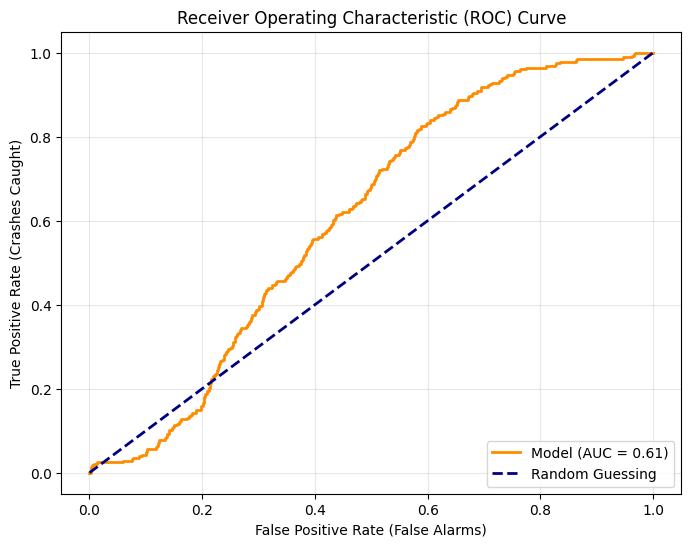


Sample Successful 'Bubble Bursts' Predicted:
      Date         Stock   Signal  Return_Next_Month
2020-03-09 CCL UN Equity 0.000172          -0.329807
2020-03-10 HAL UN Equity 0.000147          -0.314088
2020-03-13 MHK UN Equity 0.000177          -0.325767
2020-03-13 LKQ UW Equity 0.000164          -0.361446
2020-03-16 LKQ UW Equity 0.000166          -0.317289


In [6]:
# ... Inside main() after your GNN training/testing ...

def evaluate_predictive_power(test_results, prices, forward_window=22, crash_threshold=-0.10):
    """
    Calculates accuracy by checking if high signals actually lead to price drops.
    
    Args:
        forward_window: Days to look ahead (e.g., 22 days = 1 month)
        crash_threshold: Return threshold to define a 'Real Crash' (e.g., -0.10 means -10% drop)
    """
    print("\n[Accuracy Evaluation] Calculating Predictive Power...")
    
    y_true = []   # 1 if stock actually crashed, 0 otherwise
    y_scores = [] # Your anomaly signal
    
    # List to track specific successful predictions for debugging
    successful_calls = []
    
    sorted_dates = sorted(list(test_results.keys()))
    
    # We stop early so we have enough data for the forward window
    valid_dates = [d for d in sorted_dates if d <= prices.index[-1] - pd.Timedelta(days=forward_window*1.5)]
    
    for t in valid_dates:
        stocks, signals = test_results[t]
        
        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()
        signals = signals.flatten()
        
        # Calculate Forward Returns for these stocks
        # Get price at t
        p_t = prices.loc[t, stocks]
        
        # Get price at t + window
        # Find nearest valid date in future
        future_idx = prices.index.searchsorted(t + pd.Timedelta(days=forward_window))
        if future_idx >= len(prices): continue
        future_date = prices.index[future_idx]
        p_future = prices.loc[future_date, stocks]
        
        # Return calculation
        fwd_returns = (p_future - p_t) / p_t
        
        # Define Ground Truth: Did it crash?
        # If return < -10%, it is a "True Anomaly" (Class 1)
        is_crash = (fwd_returns < crash_threshold).astype(int)
        
        y_true.extend(is_crash.values)
        y_scores.extend(signals)
        
        # Track Top Predictions
        # Combine into dataframe
        df_eval = pd.DataFrame({'Stock': stocks, 'Signal': signals, 'Return': fwd_returns, 'Crash': is_crash})
        top_picks = df_eval.sort_values('Signal', ascending=False).head(5)
        
        for _, row in top_picks.iterrows():
            if row['Crash'] == 1:
                successful_calls.append({
                    'Date': t.strftime('%Y-%m-%d'),
                    'Stock': row['Stock'],
                    'Signal': row['Signal'],
                    'Return_Next_Month': row['Return']
                })

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    
    # --- METRIC 1: AUC-ROC ---
    # Can the model distinguish between a crash and normal price action?
    auc = roc_auc_score(y_true, y_scores)
    
    # --- METRIC 2: Information Coefficient (IC) ---
    # Correlation between Signal and Crash Probability
    # Ideally Positive (Higher Signal = Higher Probability of Crash)
    ic = np.corrcoef(y_scores, y_true)[0, 1]
    
    # --- METRIC 3: Precision @ Top 10% ---
    # If we take the top 10% highest signals, what % were actually crashes?
    threshold_top_10 = np.percentile(y_scores, 90)
    high_signal_indices = y_scores > threshold_top_10
    
    precision_top_10 = np.mean(y_true[high_signal_indices]) # % of high signals that were crashes
    baseline_crash_rate = np.mean(y_true) # % of ALL stocks that crashed
    
    # Lift: How much better is the model than random chance?
    lift = precision_top_10 / baseline_crash_rate if baseline_crash_rate > 0 else 0
    
    print("-" * 60)
    print(f"PREDICTIVE ACCURACY (Forward Window: {forward_window} days, Crash Threshold: {crash_threshold*100}%)")
    print("-" * 60)
    print(f"1. AUC-ROC Score:      {auc:.4f}  (0.5 = Random, >0.6 = Good, >0.7 = Excellent)")
    print(f"2. Info Coefficient:   {ic:.4f}   (Correlation with actual crashes)")
    print(f"3. Precision (Top 10%):{precision_top_10:.2%} (Of highest signals, this % actually crashed)")
    print(f"4. Baseline Crash Rate:{baseline_crash_rate:.2%} (Random probability of a crash)")
    print(f"5. Model Lift:         {lift:.2f}x    (Model is {lift:.1f} times better than random guessing)")
    print("-" * 60)
    
    # --- Visualization: ROC Curve ---
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"Model (AUC = {auc:.2f})", color='darkorange', lw=2)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
    plt.xlabel('False Positive Rate (False Alarms)')
    plt.ylabel('True Positive Rate (Crashes Caught)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    print("\nSample Successful 'Bubble Bursts' Predicted:")
    print(pd.DataFrame(successful_calls).head(10).to_string(index=False))

def load_and_fix_index(filename):
    df = pd.read_csv(filename, index_col=0)
    df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
    df = df[~df.index.duplicated(keep='last')]
    df.dropna(how='all', inplace=True)
    df = df.ffill().bfill()
    return df

# Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')   
Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')
sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', 
                        header=0, index_col=0)
sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes
# Example placeholder setup to make this runnable in context
# Replace these lines with your actual data loading block
# ---------------------------------------------------------
returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
returns.columns = returns.columns.get_level_values(0)
returns.dropna(how='all', inplace=True) 
returns = returns.pct_change().dropna(how='all')
returns = returns.ffill().bfill()
all_stocks = returns.columns.get_level_values(0).unique().tolist()
# ---------------------------------------------------------
train_returns = returns.loc['2012-01-01':'2019-12-31']
test_returns = returns.loc['2020-01-01':'2024-12-31']
volatility = returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
feature_dfs_list = [
    Market_caps, PE_ratios, Implied_vol, Beta, 
    Operating_margin, Return_on_equity, RSI_momentum, 
    Short_interest, Turnover, volatility
]
K = 21
# Train/Test Split
train_dates = train_returns.index # Example subset
test_dates = test_returns.index
prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)
test_prices = prices.loc['2020-01-01':'2024-01-31']
train_prices = prices.loc['2012-01-01':'2019-12-31']
train_volatility = volatility.loc['2012-01-01':'2019-12-31']

print("\n--- Running Regression Baseline Comparison ---")
reg_results = run_regression_comparison(
    prices, returns, sectors, train_volatility, Market_caps, PE_ratios, 
    Implied_vol, Short_interest, Beta, Operating_margin, 
    Return_on_equity, RSI_momentum, Turnover, 
    train_dates, test_dates
)

# Evaluate Baseline
print("\n[Regression Baseline Results]")
evaluate_predictive_power(reg_results, test_prices, forward_window=5, crash_threshold=-0.3)

In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import torch


def evaluate_once(
        test_results,
        prices,
        forward_window,
        crash_threshold
):

    y_true = []
    y_scores = []

    sorted_dates = sorted(test_results.keys())

    valid_dates = [
        d for d in sorted_dates
        if d <= prices.index[-1] - pd.Timedelta(days=forward_window)
    ]

    for t in valid_dates:

        stocks, signals = test_results[t]

        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()

        signals = signals.flatten()

        available = [s for s in stocks if s in prices.columns]

        if len(available) == 0:
            continue

        mask = [i for i,s in enumerate(stocks) if s in available]

        signals = signals[mask]

        p_t = prices.loc[t, available]

        future_idx = prices.index.searchsorted(
            t + pd.Timedelta(days=forward_window)
        )

        if future_idx >= len(prices):
            continue

        future_date = prices.index[future_idx]

        p_future = prices.loc[future_date, available]

        fwd_returns = (p_future - p_t) / p_t

        crash = (fwd_returns < crash_threshold).astype(int)

        y_true.extend(crash.values)

        y_scores.extend(signals)

    if len(y_true) == 0:
        return None

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    auc = roc_auc_score(y_true, y_scores)

    baseline = y_true.mean()

    precision = y_true[y_scores > np.percentile(y_scores, 90)].mean()

    lift = precision / baseline if baseline > 0 else np.nan

    return auc, lift, baseline

def grid_search(
        test_results,
        prices,
        forward_windows,
        crash_thresholds
):

    rows = []

    for fw in forward_windows:

        for ct in crash_thresholds:

            result = evaluate_once(
                test_results,
                prices,
                fw,
                ct
            )

            if result is None:
                continue

            auc, lift, baseline = result

            rows.append({

                "ForwardWindow": fw,

                "CrashThreshold": ct,

                "AUC": auc,

                "Lift": lift,

                "Baseline": baseline

            })

            print(
                f"FW={fw:3d} "
                f"CT={ct:6.2f} "
                f"AUC={auc:.3f} "
                f"Lift={lift:.2f}"
            )

    return pd.DataFrame(rows)


In [8]:
forward_windows = [5,10,22,44,66]

crash_thresholds = [-0.05,-0.10,-0.15,-0.20,-0.30]

#test_results = pd.read_pickle("outputs/test_results_test_fix3Mar.pkl")

#test_prices = pd.read_pickle("outputs/test_prices_test_fix3Mar.pkl") 

df_results = grid_search(

    reg_results,

    test_prices,

    forward_windows,

    crash_thresholds

)
# for test_results_test : FW=  5 CT= -0.30 AUC=0.785 Lift=4.45 testing from 2020-2024


FW=  5 CT= -0.05 AUC=0.574 Lift=1.65
FW=  5 CT= -0.10 AUC=0.573 Lift=1.75
FW=  5 CT= -0.15 AUC=0.551 Lift=1.34
FW=  5 CT= -0.20 AUC=0.544 Lift=0.95
FW=  5 CT= -0.30 AUC=0.607 Lift=0.46
FW= 10 CT= -0.05 AUC=0.571 Lift=1.50
FW= 10 CT= -0.10 AUC=0.586 Lift=1.75
FW= 10 CT= -0.15 AUC=0.559 Lift=1.50
FW= 10 CT= -0.20 AUC=0.516 Lift=1.06
FW= 10 CT= -0.30 AUC=0.511 Lift=0.51
FW= 22 CT= -0.05 AUC=0.551 Lift=1.40
FW= 22 CT= -0.10 AUC=0.564 Lift=1.62
FW= 22 CT= -0.15 AUC=0.543 Lift=1.60
FW= 22 CT= -0.20 AUC=0.508 Lift=1.42
FW= 22 CT= -0.30 AUC=0.468 Lift=0.84
FW= 44 CT= -0.05 AUC=0.559 Lift=1.40
FW= 44 CT= -0.10 AUC=0.572 Lift=1.54
FW= 44 CT= -0.15 AUC=0.560 Lift=1.52
FW= 44 CT= -0.20 AUC=0.520 Lift=1.45
FW= 44 CT= -0.30 AUC=0.451 Lift=1.16
FW= 66 CT= -0.05 AUC=0.555 Lift=1.31
FW= 66 CT= -0.10 AUC=0.570 Lift=1.46
FW= 66 CT= -0.15 AUC=0.575 Lift=1.55
FW= 66 CT= -0.20 AUC=0.560 Lift=1.45
FW= 66 CT= -0.30 AUC=0.544 Lift=1.28



[Accuracy Evaluation] Calculating Predictive Power...
------------------------------------------------------------
PREDICTIVE ACCURACY (Forward Window: 5 days, Crash Threshold: -30.0%)
------------------------------------------------------------
1. AUC-ROC Score:      0.6064  (0.5 = Random, >0.6 = Good, >0.7 = Excellent)
2. Info Coefficient:   0.0017   (Correlation with actual crashes)
3. Precision (Top 10%):0.02% (Of highest signals, this % actually crashed)
4. Baseline Crash Rate:0.05% (Random probability of a crash)
5. Model Lift:         0.43x    (Model is 0.4 times better than random guessing)
------------------------------------------------------------


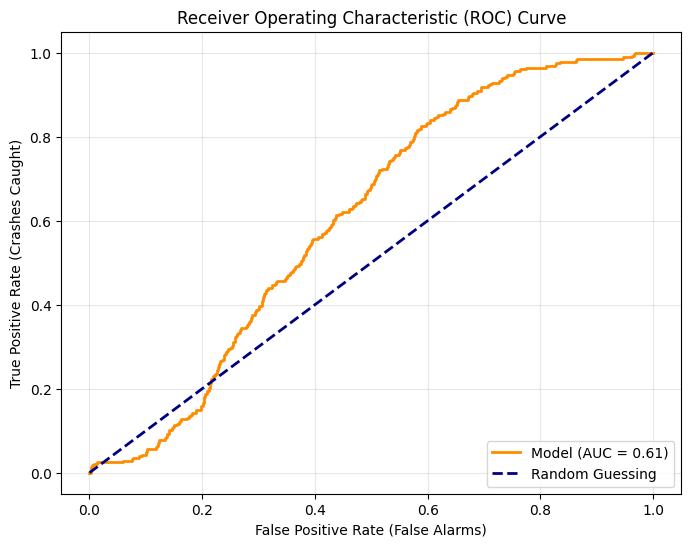


Sample Successful 'Bubble Bursts' Predicted:
      Date         Stock   Signal  Return_Next_Month
2020-03-09 CCL UN Equity 0.000172          -0.329807
2020-03-10 HAL UN Equity 0.000147          -0.314088
2020-03-13 MHK UN Equity 0.000177          -0.325767
2020-03-13 LKQ UW Equity 0.000164          -0.361446
2020-03-16 LKQ UW Equity 0.000166          -0.317289


In [9]:
evaluate_predictive_power(reg_results, test_prices, forward_window=5, crash_threshold=-0.30)

[5] Visualizing Average Anomaly Signal (Regression Baseline)...


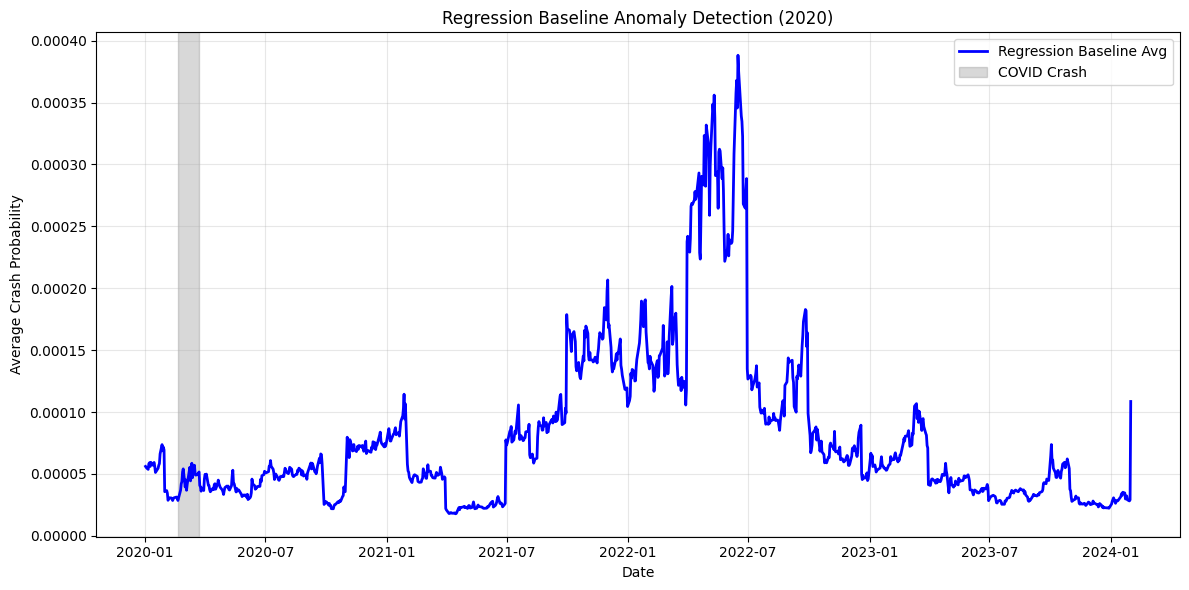

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("[5] Visualizing Average Anomaly Signal (Regression Baseline)...")

# 1. Convert the dictionary results into a pandas Series of average scores
# reg_results structure: {date: (active_stocks_list, probabilities_array)}
date_map = {}

for date, (stocks, probs) in reg_results.items():
    # We take the mean of the probabilities for that specific day
    date_map[date] = np.mean(probs)

# Create a Series sorted by date
avg_signals = pd.Series(date_map).sort_index()

# 2. Filter for 2020
try:
    # Slice the series for the year 2020
    avg_signals_2020 = avg_signals.loc['2020-01-01':'2024-01-31']
except KeyError:
    print("Warning: Date range not found in data.")
    avg_signals_2020 = pd.Series()

# 3. Plot
if not avg_signals_2020.empty:
    plt.figure(figsize=(12, 6))

    # Plot directly using the index (dates) and values
    plt.plot(avg_signals_2020.index, avg_signals_2020.values, color='blue', linewidth=2, label='Regression Baseline Avg')

    # Highlight COVID Crash
    plt.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-03-23'), 
                color='grey', alpha=0.3, label='COVID Crash')

    plt.title("Regression Baseline Anomaly Detection (2020)")
    plt.ylabel("Average Crash Probability")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for 2020.")